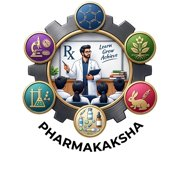

# BP301T · Unit I — Foundations of Machine Learning
**Pharmakaksha · Learn · Grow · Achieve**
*Introduction to Machine Learning in Pharmaceutical Sciences · B.Pharm Semester III · PCI NEP 2020*

This notebook contains every example and demo from the Unit I study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit1_Foundations_of_ML.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/BP301T_Unit1_Foundations_of_ML.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import sklearn` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data (except scikit-learn's built-in breast-cancer dataset). The models are for learning machine learning only. They are not clinical tools.

## 1.1 AI, machine learning and data science
**Machine learning (ML)** means learning patterns from data instead of writing every rule by hand. Compare the two approaches on a simple task: flagging a patient for a renal dose check.

In [ ]:
# Traditional programming: a pharmacist writes the rule
def renal_flag(crcl):
    return "Dose check" if crcl < 50 else "OK"

print(renal_flag(35), renal_flag(90))

In machine learning we give the computer **examples with answers**, and it finds the rule itself. You will see this in section 1.5.

## 1.2 Types of learning
| Type | Data | Pharma example |
|---|---|---|
| Supervised | Features **and** labels | Predict ADR yes/no; predict clearance |
| Unsupervised | Features only | Group patients into segments |
| Reinforcement | Actions and rewards | An agent learns a dosing strategy by trial and reward (research stage) |

## 1.3 Features and labels
The practice dataset `adr_patients.csv` holds 400 fictional patients. Each row is one patient. This cell loads it (from this folder, or from GitHub when you use Colab).

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP301T%20Introduction%20to%20Machine%20Learning%20in%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

adr = load("adr_patients.csv")
print(adr.shape)
adr.head()

The **label** (target, *y*) is what we want to predict: `adr` (1 = the patient had an adverse drug reaction). The **features** (*X*) are the inputs used to predict it. Text categories such as `sex` must become numbers first.

In [ ]:
adr["female"] = (adr["sex"] == "F").astype(int)      # encode M/F as 0/1

features = ["age", "female", "weight_kg", "crcl_ml_min", "num_drugs", "liver_disease", "prior_adr"]
X = adr[features]          # feature matrix (capital X)
y = adr["adr"]             # label vector (small y)

print(X.shape, y.shape)
print(y.value_counts())

## 1.4 Training data, test data and the train–test split
A model is judged on patients it has **never seen**. We hold back 25% of the rows as a test set. `stratify=y` keeps the same ADR percentage in both parts, and `random_state` makes the split repeatable.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("ADR rate  train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

## 1.5 Model building and prediction
Every scikit-learn model follows the same four steps: **import → create → fit → predict**. Our first model predicts a drug's **clearance** (L/h) from creatinine clearance using `pk_clearance.csv` (60 fictional patients).

In [ ]:
from sklearn.linear_model import LinearRegression

pk = load("pk_clearance.csv")
X_pk = pk[["crcl_ml_min"]]          # double brackets: X must be a table
y_pk = pk["clearance_L_h"]

model = LinearRegression()          # 1-2. import and create
model.fit(X_pk, y_pk)               # 3. fit = learn from the examples

print("Slope:", round(model.coef_[0], 4), " Intercept:", round(model.intercept_, 3))
new_patients = pd.DataFrame({"crcl_ml_min": [30, 60, 100]})
print("Predicted clearance (L/h):", model.predict(new_patients).round(2))   # 4. predict

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(pk["crcl_ml_min"], pk["clearance_L_h"], color="#17725C", alpha=0.8, label="Patients")
xs = pd.DataFrame({"crcl_ml_min": np.linspace(10, 155, 50)})
plt.plot(xs["crcl_ml_min"], model.predict(xs), color="#E07A2E", linewidth=2.5, label="Learned line")
plt.xlabel("Creatinine clearance (mL/min)")
plt.ylabel("Drug clearance (L/h)")
plt.title("The model learns the CrCl–clearance relationship")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**A baseline first.** For the ADR data, a "model" that always predicts *no ADR* is already right for 79% of test patients. Any real model must beat this.

In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Baseline accuracy:", round(baseline.score(X_test, y_test), 3))

## 1.6 Overfitting, underfitting and the bias–variance trade-off
We fit curves of increasing complexity (polynomial degree) to 20 noisy dose–response points and check the error on fresh test points.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(1)
def emax(d):                                     # the true dose–response curve
    return 100 * d / (d + 15)

d_train = np.sort(rng.uniform(0, 60, 20))                       # 20 training doses
r_train = emax(d_train) + rng.normal(0, 6, 20)                  # + measurement noise
d_test = np.sort(rng.uniform(d_train.min(), d_train.max(), 40)) # 40 new doses
r_test = emax(d_test) + rng.normal(0, 6, 40)

def poly_model(deg):
    """A curve of the given degree (dose is scaled to 0–1 first)."""
    m = make_pipeline(PolynomialFeatures(deg), StandardScaler(), LinearRegression())
    return m.fit((d_train / 60).reshape(-1, 1), r_train)

def rmse(m, d, r):
    return np.sqrt(mean_squared_error(r, m.predict((d / 60).reshape(-1, 1))))

grid = np.linspace(d_train.min(), d_train.max(), 300)
plt.figure(figsize=(11, 4))
for i, deg in enumerate([1, 3, 12], start=1):
    m = poly_model(deg)
    plt.subplot(1, 3, i)
    plt.scatter(d_train, r_train, color="#12303A", s=25)
    plt.plot(grid, m.predict((grid / 60).reshape(-1, 1)), color="#E07A2E", linewidth=2)
    plt.ylim(-20, 130); plt.xlabel("Dose (mg)")
    if i == 1: plt.ylabel("Response (%)")
    plt.title(f"Degree {deg}\ntrain RMSE {rmse(m, d_train, r_train):.1f} | test RMSE {rmse(m, d_test, r_test):.1f}")
plt.tight_layout(); plt.show()

In [ ]:
degrees = range(1, 13)
train_err = [rmse(poly_model(d), d_train, r_train) for d in degrees]
test_err = [rmse(poly_model(d), d_test, r_test) for d in degrees]
print("Training error:", np.round(train_err, 1))
print("Test error:    ", np.round(test_err, 1))
print("Lowest test error at degree", list(degrees)[int(np.argmin(test_err))])

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_err, marker="o", color="#12303A", label="Training error")
plt.plot(degrees, test_err, marker="s", color="#E07A2E", linestyle="--", label="Test error")
plt.axvline(3, color="grey", linestyle=":")
plt.text(1.2, 40, "Underfitting\n(high bias)", color="#12303A")
plt.text(5.5, 40, "Overfitting\n(high variance)", color="#9A4A12")
plt.ylim(0, 50)
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("RMSE (% response)")
plt.title("Bias–variance trade-off")
plt.legend(loc="upper center"); plt.grid(alpha=0.3); plt.show()

## 1.7 The ML workflow
1. Define the problem → 2. Collect data → 3. Clean and prepare → 4. Split → 5. Train → 6. Evaluate → 7. Deploy and monitor.

## Worked example: predicting drug clearance end to end
We now use **two** features (CrCl and weight) and follow every step of the workflow.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Steps 2–3: load and check the data
pk = load("pk_clearance.csv")
print(pk.isna().sum().sum(), "missing values")

# Step 4: features, label, split
X = pk[["crcl_ml_min", "weight_kg"]]
y = pk["clearance_L_h"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 5: train
model = LinearRegression().fit(X_train, y_train)

# Step 6: evaluate on unseen patients
pred = model.predict(X_test)
print("Mean absolute error:", round(mean_absolute_error(y_test, pred), 2), "L/h")

# Use it: a 70 kg patient with CrCl 45 mL/min
new = pd.DataFrame({"crcl_ml_min": [45], "weight_kg": [70]})
print("Predicted clearance:", round(model.predict(new)[0], 2), "L/h")

## Quick check
A model scores 99% on its training data but 70% on the test data. Is it underfitting or overfitting? Decide, then run the cell.

In [ ]:
print("Overfitting: it memorised the training data (high variance) and does not generalise.")

## Try it yourself (lab)
Write your code in the empty cells. Solutions are at the end of the notebook.

**1.** Load `adr_patients.csv` and print how many patients had an ADR and what percentage that is.

**2.** Split the ADR data 80/20 (`test_size=0.2`, `random_state=1`, stratified). Print the number of rows in each part.

**3.** Fit a `LinearRegression` that predicts clearance from `age` alone. Is the slope positive or negative? Why might that be?

**4.** In the bias–variance demo, which degree gave the lowest test error? Re-run it with `degrees = range(1, 8)`.

---
## Solutions

In [ ]:
# 1
adr = load("adr_patients.csv")
print(adr["adr"].sum(), "patients,", round(100 * adr["adr"].mean(), 1), "%")

In [ ]:
# 2
adr["female"] = (adr["sex"] == "F").astype(int)
X = adr[["age", "female", "weight_kg", "crcl_ml_min", "num_drugs", "liver_disease", "prior_adr"]]
Xtr, Xte, ytr, yte = train_test_split(X, adr["adr"], test_size=0.2, random_state=1, stratify=adr["adr"])
print(len(Xtr), len(Xte))

In [ ]:
# 3
pk = load("pk_clearance.csv")
m = LinearRegression().fit(pk[["age"]], pk["clearance_L_h"])
print(round(m.coef_[0], 3))   # negative: kidney function (and so clearance) falls with age

In [ ]:
# 4
test_err = [rmse(poly_model(d), d_test, r_test) for d in range(1, 8)]
print("Best degree:", int(np.argmin(test_err)) + 1)

---
**Next:** Unit II — Regression Models in Healthcare. Pharmakaksha · Learn · Grow · Achieve